# Notebook 05: Advanced Evaluation Metrics
## Beyond Accuracy with Statistical and Business Rigor

This notebook is a full evaluation workflow for classification systems. It focuses on practical reliability: not only whether a model performs well, but whether reported metrics are stable, calibrated, and aligned with business cost.

### Learning objectives
1. Understand why accuracy alone is incomplete, especially under class imbalance
2. Compute confusion-matrix-based metrics from first principles
3. Compare ROC-AUC and PR-AUC under different class distributions
4. Quantify uncertainty with bootstrap confidence intervals
5. Optimize decision thresholds for explicit business cost
6. Evaluate multiclass systems with macro, weighted, and micro strategies
7. Inspect probability quality with calibration analysis

### Prerequisites
- Binary and multiclass classification basics
- Probability and conditional probability
- Matrix/vector familiarity

## 1. Setup and reproducibility

We use deterministic seeds and fixed splits so every rerun is consistent. This is critical for experimentation and peer review.

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    cohen_kappa_score,
    log_loss,
    brier_score_loss,
    balanced_accuracy_score,
    matthews_corrcoef
)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [2]:
# Cell 2: Helper printing function
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Environment ready")
print(f"Random state: {RANDOM_STATE}")

Environment ready
Random state: 42


## 2. Why accuracy can fail

Accuracy can appear high even when the model misses most positive cases. In rare-event settings (fraud, defects, severe disease), this is a common failure mode.

We create a synthetic imbalanced dataset to make the issue explicit.

In [3]:
# Cell 3: Generate imbalanced binary dataset
X, y = make_classification(
    n_samples=2500,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    weights=[0.94, 0.06],
    class_sep=1.2,
    flip_y=0.01,
    random_state=RANDOM_STATE
)

print("Dataset generated")
print(f"Shape: {X.shape}")

Dataset generated
Shape: (2500, 20)


In [4]:
# Cell 4: Class distribution report
unique, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({"class": unique, "count": counts})
class_dist["pct"] = class_dist["count"] / class_dist["count"].sum() * 100

print(class_dist)
print(f"Imbalance ratio (majority:minority) = {counts[0] / counts[1]:.2f}:1")

   class  count    pct
0      0   2338  93.52
1      1    162   6.48
Imbalance ratio (majority:minority) = 14.43:1


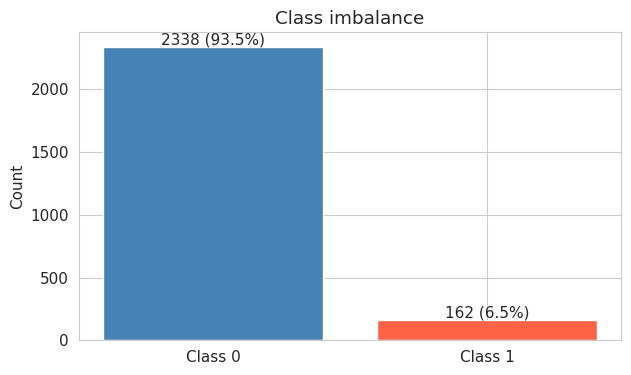

In [5]:
# Cell 5: Visualize class imbalance
plt.figure(figsize=(7, 4))
plt.bar(["Class 0", "Class 1"], counts, color=["steelblue", "tomato"])
plt.title("Class imbalance")
plt.ylabel("Count")
for i, c in enumerate(counts):
    plt.text(i, c + 20, f"{c} ({100*c/len(y):.1f}%)", ha="center")
plt.show()

### Data split and scaling protocol

Protocol matters for valid evaluation:
1. Split once with stratification
2. Fit preprocessing only on training data
3. Apply transform to train and test

This prevents information leakage from test set statistics.

In [6]:
# Cell 6: Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train minority rate:", y_train.mean().round(4))
print("Test minority rate:", y_test.mean().round(4))

Train size: (1750, 20)
Test size: (750, 20)
Train minority rate: 0.0646
Test minority rate: 0.0653


In [7]:
# Cell 7: Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print("Train mean first 3 features:", np.mean(X_train_scaled, axis=0)[:3].round(3))
print("Train std first 3 features:", np.std(X_train_scaled, axis=0)[:3].round(3))

Scaling done
Train mean first 3 features: [ 0.  0. -0.]
Train std first 3 features: [1. 1. 1.]


## 3. Baseline models and the accuracy trap

We train two baselines:
- Model A: standard logistic regression
- Model B: class-weight-balanced logistic regression

This shows how different training objectives alter operating behavior.

In [8]:
# Cell 8: Model A (default logistic regression)
model_a = LogisticRegression(max_iter=1500, random_state=RANDOM_STATE)
model_a.fit(X_train_scaled, y_train)

y_pred_a = model_a.predict(X_test_scaled)
y_prob_a = model_a.predict_proba(X_test_scaled)[:, 1]

print("Model A trained")

Model A trained


In [9]:
# Cell 9: Model B (class_weight='balanced')
model_b = LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, class_weight="balanced")
model_b.fit(X_train_scaled, y_train)

y_pred_b = model_b.predict(X_test_scaled)
y_prob_b = model_b.predict_proba(X_test_scaled)[:, 1]

print("Model B trained")

Model B trained


In [10]:
# Cell 10: Compare headline metrics
summary = pd.DataFrame([
    {
        "model": "A_default",
        "accuracy": accuracy_score(y_test, y_pred_a),
        "precision": precision_score(y_test, y_pred_a, zero_division=0),
        "recall": recall_score(y_test, y_pred_a, zero_division=0),
        "f1": f1_score(y_test, y_pred_a, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_a)
    },
    {
        "model": "B_balanced",
        "accuracy": accuracy_score(y_test, y_pred_b),
        "precision": precision_score(y_test, y_pred_b, zero_division=0),
        "recall": recall_score(y_test, y_pred_b, zero_division=0),
        "f1": f1_score(y_test, y_pred_b, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_b)
    }
])

print(summary.round(4))

        model  accuracy  precision  recall      f1  balanced_accuracy
0   A_default    0.9267     0.2000  0.0408  0.0678             0.5147
1  B_balanced    0.7507     0.1584  0.6531  0.2550             0.7053


The key observation: a model can increase recall by sacrificing precision while keeping accuracy deceptively high. This is why evaluation must include confusion-matrix-aware metrics.

## 4. Confusion matrix and first-principles metrics

The **confusion matrix** is the bedrock of classification evaluation. It provides a complete picture of a model's performance by breaking down predictions into four categories. For a binary classification problem, these are:

- **True Positives (TP):** Correctly predicted positive cases. (e.g., actual fraud correctly identified as fraud).
- **True Negatives (TN):** Correctly predicted negative cases. (e.g., legitimate transactions correctly identified as legitimate).
- **False Positives (FP):** Incorrectly predicted positive cases (a "Type I error"). (e.g., a legitimate transaction incorrectly flagged as fraud).
- **False Negatives (FN):** Incorrectly predicted negative cases (a "Type II error"). (e.g., actual fraud that was missed and classified as legitimate).

From these four values, we can derive more intuitive and robust metrics:

$$ Precision = \frac{TP}{TP + FP} $$
*Measures the accuracy of positive predictions. Answers: "Of all the transactions we flagged as fraud, what proportion was actually fraud?"*

$$ Recall (Sensitivity) = \frac{TP}{TP + FN} $$
*Measures the model's ability to find all positive instances. Answers: "Of all the actual fraud transactions, what proportion did we successfully catch?"*

$$ F1-Score = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} $$
*The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, and is particularly useful when you need a balance between the two, such as in our imbalanced dataset scenario.*


In [11]:
# Cell 12: Confusion matrix for balanced model
cm = confusion_matrix(y_test, y_pred_b)
TN, FP, FN, TP = cm.ravel()

print('Confusion matrix:')
print(cm)
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")


Confusion matrix:
[[531 170]
 [ 17  32]]
TN=531, FP=170, FN=17, TP=32


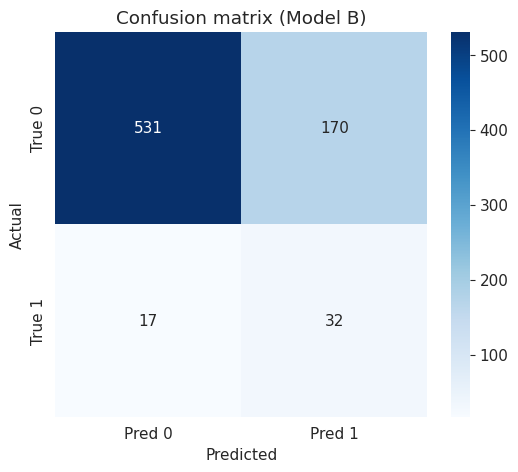

In [12]:
# Cell 13: Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)
plt.title("Confusion matrix (Model B)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# Cell 14: Manual metrics from confusion matrix
def precision_manual(tn, fp, fn, tp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_manual(tn, fp, fn, tp):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def specificity_manual(tn, fp, fn, tp):
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def f1_manual(tn, fp, fn, tp):
    p = precision_manual(tn, fp, fn, tp)
    r = recall_manual(tn, fp, fn, tp)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

manual = {
    "precision": precision_manual(TN, FP, FN, TP),
    "recall": recall_manual(TN, FP, FN, TP),
    "specificity": specificity_manual(TN, FP, FN, TP),
    "f1": f1_manual(TN, FP, FN, TP)
}

print({k: round(v, 4) for k, v in manual.items()})

{'precision': np.float64(0.1584), 'recall': np.float64(0.6531), 'specificity': np.float64(0.7575), 'f1': np.float64(0.255)}


In [14]:
# Cell 15: Verify manual vs sklearn
checks = pd.DataFrame([
    {
        "metric": "precision",
        "manual": manual["precision"],
        "sklearn": precision_score(y_test, y_pred_b, zero_division=0)
    },
    {
        "metric": "recall",
        "manual": manual["recall"],
        "sklearn": recall_score(y_test, y_pred_b, zero_division=0)
    },
    {
        "metric": "f1",
        "manual": manual["f1"],
        "sklearn": f1_score(y_test, y_pred_b, zero_division=0)
    }
])
checks["abs_diff"] = (checks["manual"] - checks["sklearn"]).abs()
print(checks.round(8))

      metric    manual   sklearn  abs_diff
0  precision  0.158416  0.158416       0.0
1     recall  0.653061  0.653061       0.0
2         f1  0.254980  0.254980       0.0


In [15]:
# Cell 16: Full classification report
print(classification_report(y_test, y_pred_b, digits=4))

              precision    recall  f1-score   support

           0     0.9690    0.7575    0.8503       701
           1     0.1584    0.6531    0.2550        49

    accuracy                         0.7507       750
   macro avg     0.5637    0.7053    0.5526       750
weighted avg     0.9160    0.7507    0.8114       750



## 5. Threshold Analysis and Business Cost Optimization

Most classifiers, including logistic regression, output a probability score (between 0 and 1), not a hard class label. The common practice of using a 0.5 threshold to classify as 'positive' is often suboptimal, especially when the consequences of different types of errors are not equal.

**The key idea is to align the classification threshold with real-world business objectives.**

Let's define a cost scenario for our fraud detection problem:
- **Cost of a False Negative (FN):** A fraudulent transaction is missed. This is typically very costly. Let's set this to **$120**.
- **Cost of a False Positive (FP):** A legitimate transaction is flagged as fraud. This is an inconvenience for the customer and has an operational cost. Let's set this to **$15**.

Our goal is to find the threshold that minimizes the total cost, which can be expressed as:

$$ \text{Total Cost} = (\text{Cost}_{FN} \times N_{FN}) + (\text{Cost}_{FP} \times N_{FP}) $$

In [16]:
# Cell 18: Cost function
def total_cost(y_true, y_pred, fn_cost=120, fp_cost=15):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn_cost * fn + fp_cost * fp

print("Cost function ready")

Cost function ready


In [17]:
# Cell 19: Sweep thresholds for Model B
thresholds = np.arange(0.01, 0.99, 0.01)
rows = []

for t in thresholds:
    y_hat = (y_prob_b >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_hat, zero_division=0),
        "recall": recall_score(y_test, y_hat, zero_division=0),
        "f1": f1_score(y_test, y_hat, zero_division=0),
        "accuracy": accuracy_score(y_test, y_hat),
        "cost": total_cost(y_test, y_hat)
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.head().round(4))

   threshold  precision  recall      f1  accuracy   cost
0       0.01     0.0659     1.0  0.1237    0.0747  10410
1       0.02     0.0668     1.0  0.1252    0.0867  10275
2       0.03     0.0682     1.0  0.1278    0.1080  10035
3       0.04     0.0695     1.0  0.1300    0.1253   9840
4       0.05     0.0703     1.0  0.1314    0.1360   9720


In [18]:
# Cell 20: Best thresholds by different objectives
best_f1 = threshold_df.loc[threshold_df["f1"].idxmax()]
best_cost = threshold_df.loc[threshold_df["cost"].idxmin()]
default_row = threshold_df.loc[np.isclose(threshold_df["threshold"], 0.5)].iloc[0]

report = pd.DataFrame([
    {"criterion": "max_f1", "threshold": best_f1["threshold"], "f1": best_f1["f1"], "cost": best_f1["cost"]},
    {"criterion": "min_cost", "threshold": best_cost["threshold"], "f1": best_cost["f1"], "cost": best_cost["cost"]},
    {"criterion": "default_0.5", "threshold": default_row["threshold"], "f1": default_row["f1"], "cost": default_row["cost"]}
])
print(report.round(4))
print("Cost saving vs default:", int(default_row["cost"] - best_cost["cost"]))

     criterion  threshold      f1    cost
0       max_f1       0.72  0.3239  4170.0
1     min_cost       0.72  0.3239  4170.0
2  default_0.5       0.50  0.2550  4590.0
Cost saving vs default: 420


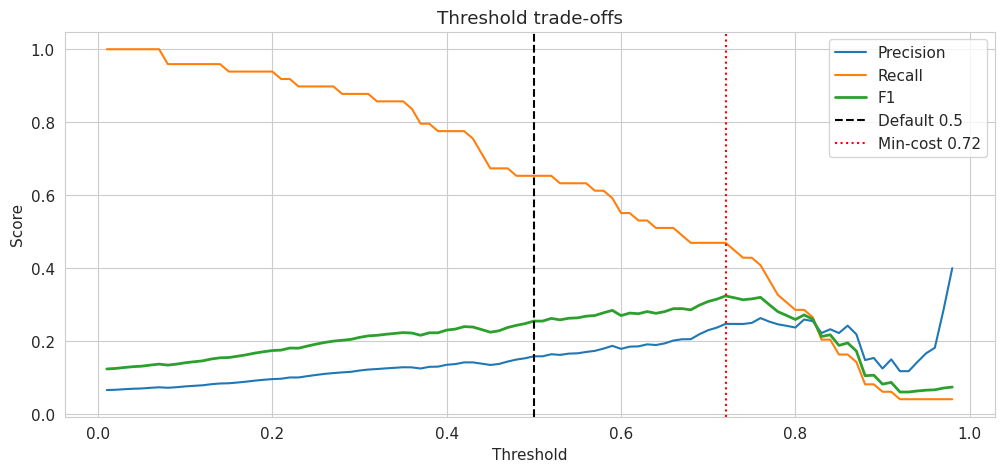

In [19]:
# Cell 21: Plot metric curves over threshold
plt.figure(figsize=(12, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", linewidth=2)
plt.axvline(0.5, color="black", linestyle="--", label="Default 0.5")
plt.axvline(best_cost["threshold"], color="red", linestyle=":", label=f"Min-cost {best_cost['threshold']:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold trade-offs")
plt.legend()
plt.show()

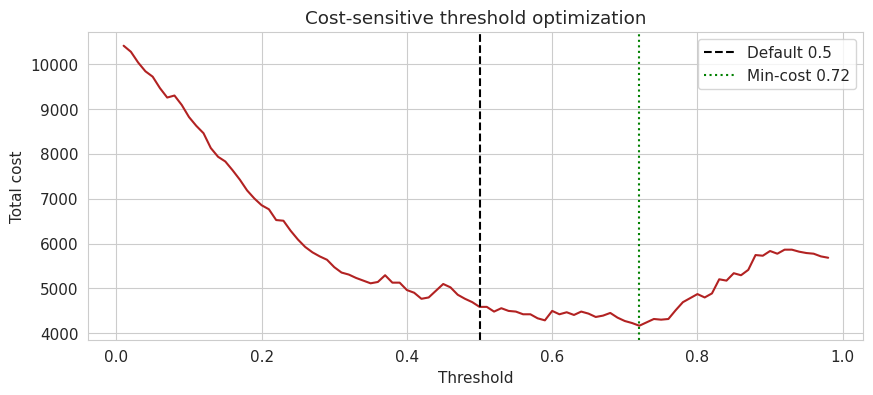

In [20]:
# Cell 22: Plot business cost curve
plt.figure(figsize=(10, 4))
plt.plot(threshold_df["threshold"], threshold_df["cost"], color="firebrick")
plt.axvline(0.5, color="black", linestyle="--", label="Default 0.5")
plt.axvline(best_cost["threshold"], color="green", linestyle=":", label=f"Min-cost {best_cost['threshold']:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total cost")
plt.title("Cost-sensitive threshold optimization")
plt.legend()
plt.show()

## 6. ROC-AUC vs. PR-AUC: Choosing the Right Tool

While both ROC-AUC and PR-AUC measure a model's ranking ability across thresholds, they are sensitive to different aspects of performance.

- **ROC Curve (Receiver Operating Characteristic):** Plots True Positive Rate (Recall) vs. False Positive Rate.
  - **TPR (Recall):**  *Proportion of actual positives correctly identified.*
  - **FPR:** *Proportion of actual negatives incorrectly identified.* 
  - **Strength:** ROC-AUC is insensitive to class imbalance. A high ROC-AUC score indicates the model is good at distinguishing between classes, regardless of their prevalence.
  - **Weakness:** In highly imbalanced datasets, a high FPR can correspond to a very large number of false positives, which might be obscured by a high AUC score. The curve doesn't focus on the performance on the minority class.

- **PR Curve (Precision-Recall):** Plots Precision vs. Recall.
  - **Precision:** *Proportion of positive predictions that are correct.*
  - **Recall (TPR):** *Proportion of actual positives correctly identified.*
  - **Strength:** PR-AUC is highly sensitive to the performance on the positive (minority) class. It is a more informative metric when the positive class is rare and you care deeply about the correctness of your positive predictions (e.g., fraud, medical diagnosis).
  - **Weakness:** Unlike ROC-AUC, the baseline for PR-AUC (the score of a random classifier) depends on the class imbalance. 

**Rule of Thumb:**
- Use **ROC-AUC** when your classes are balanced or when you are primarily concerned with the model's general discriminative ability.
- Use **PR-AUC** when your dataset is imbalanced and the performance on the minority class is more important.

In [21]:
# Cell 24: ROC curve and AUC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_b)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7806


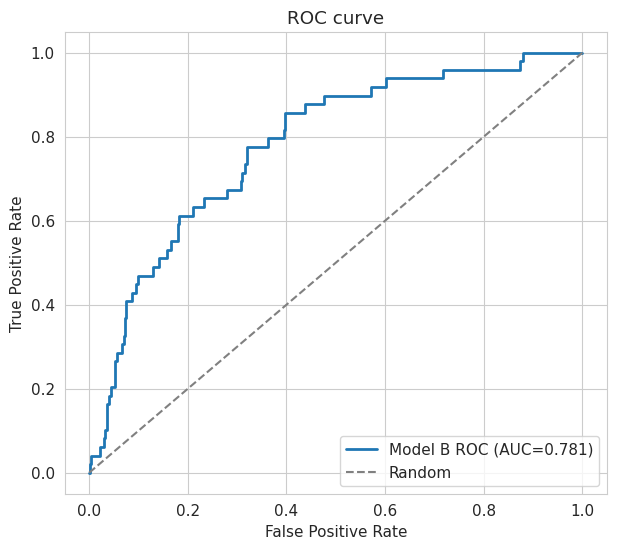

In [22]:
# Cell 25: Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Model B ROC (AUC={roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.show()

In [23]:
# Cell 26: PR curve and AP
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, y_prob_b)
ap = average_precision_score(y_test, y_prob_b)

print(f"Average Precision (PR-AUC proxy): {ap:.4f}")

Average Precision (PR-AUC proxy): 0.1950


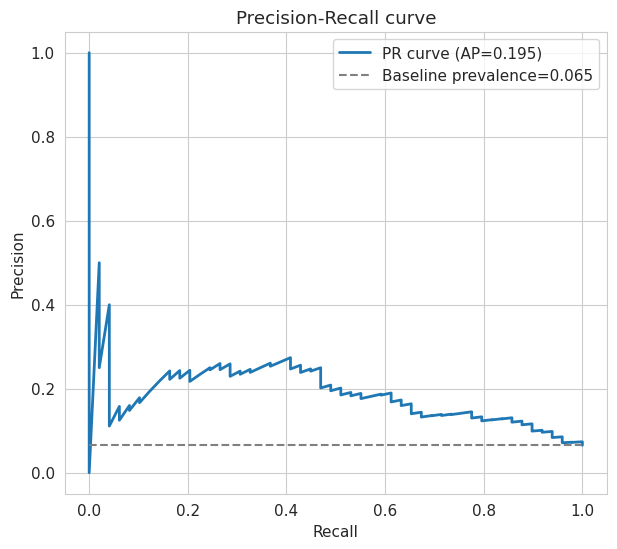

In [24]:
# Cell 27: Plot PR curve
plt.figure(figsize=(7, 6))
plt.plot(rec_curve, prec_curve, linewidth=2, label=f"PR curve (AP={ap:.3f})")
base_rate = y_test.mean()
plt.hlines(base_rate, 0, 1, linestyle="--", color="gray", label=f"Baseline prevalence={base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend(loc="upper right")
plt.show()

## 7. Uncertainty with Bootstrap Confidence Intervals

A single performance metric (like an F1-score of 0.53) is only a **point estimate**. It's a single value calculated from our specific, limited test set. If we had a slightly different test set, we would get a slightly different F1-score. The question is, how much different? This is the problem of **sampling variability**.

**Bootstrapping** is a powerful statistical method that allows us to estimate the uncertainty of a metric without making strong assumptions about the underlying data distribution. It simulates the process of drawing new samples from the population.

### The Procedure
1.  **Resample:** From our test set of size N, we create a new, "bootstrapped" sample of the same size by drawing N data points *with replacement*. This means some original data points might appear multiple times in the bootstrapped sample, while others might not appear at all.
2.  **Recompute:** We calculate our desired metric (e.g., F1-score) on this new bootstrapped sample.
3.  **Repeat:** We repeat this process many times (e.g., 800-1000 times), each time recording the metric.
4.  **Estimate Confidence Interval:** We now have a distribution of our metric (e.g., 800 F1-scores). We can find a 95% confidence interval by taking the 2.5th and 97.5th percentiles of this distribution. This gives us a range in which we can be 95% confident the "true" metric lies.

In [25]:
# Cell 29: Bootstrap utility
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=800, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))
    vals = np.asarray(vals)
    alpha = 1 - ci
    lo = np.percentile(vals, 100 * alpha / 2)
    hi = np.percentile(vals, 100 * (1 - alpha / 2))
    return vals.mean(), lo, hi, vals

print("Bootstrap helper ready")

Bootstrap helper ready


In [26]:
# Cell 30: Bootstrap CI for key metrics at min-cost threshold
best_threshold = float(best_cost["threshold"])
y_pred_best = (y_prob_b >= best_threshold).astype(int)

metric_map = {
    "accuracy": accuracy_score,
    "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
    "recall": lambda yt, yp: recall_score(yt, yp, zero_division=0),
    "f1": lambda yt, yp: f1_score(yt, yp, zero_division=0)
}

ci_rows = []
for name, fn in metric_map.items():
    mean_v, lo, hi, _ = bootstrap_ci(y_test, y_pred_best, fn, n_boot=500, ci=0.95, random_state=RANDOM_STATE)
    ci_rows.append({"metric": name, "mean": mean_v, "ci_low": lo, "ci_high": hi, "width": hi - lo})

ci_df = pd.DataFrame(ci_rows)
print(ci_df.round(4))

      metric    mean  ci_low  ci_high   width
0   accuracy  0.8724  0.8493   0.8954  0.0460
1  precision  0.2452  0.1582   0.3350  0.1768
2     recall  0.4670  0.3090   0.6037  0.2948
3         f1  0.3201  0.2203   0.4170  0.1967


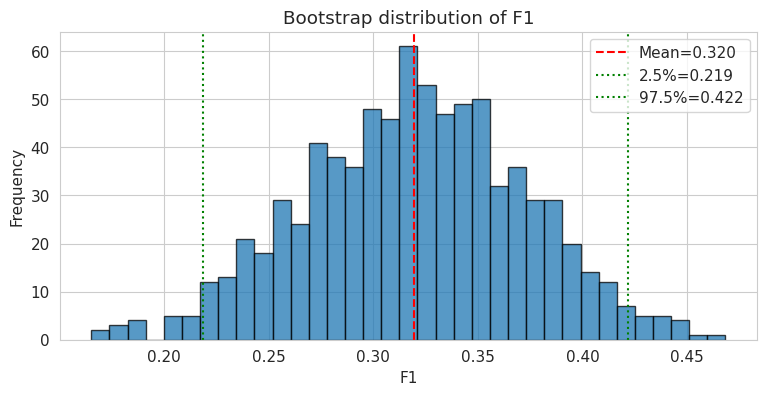

In [27]:
# Cell 31: Bootstrap distribution for F1
_, lo_f1, hi_f1, f1_samples = bootstrap_ci(
    y_test,
    y_pred_best,
    lambda yt, yp: f1_score(yt, yp, zero_division=0),
    n_boot=800,
    ci=0.95,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 4))
plt.hist(f1_samples, bins=35, alpha=0.75, edgecolor="black")
plt.axvline(np.mean(f1_samples), color="red", linestyle="--", label=f"Mean={np.mean(f1_samples):.3f}")
plt.axvline(lo_f1, color="green", linestyle=":", label=f"2.5%={lo_f1:.3f}")
plt.axvline(hi_f1, color="green", linestyle=":", label=f"97.5%={hi_f1:.3f}")
plt.title("Bootstrap distribution of F1")
plt.xlabel("F1")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 8. Probability Calibration

A good classifier not only ranks instances correctly (as measured by AUC) but also outputs **well-calibrated probabilities**. 

**What is a calibrated probability?**
If a model is well-calibrated, then for all instances where it predicts a probability of, say, 0.8, approximately 80% of those instances should actually belong to the positive class.

**Why does it matter?**
- **Risk Assessment:** When probabilities are used to make high-stakes decisions (e.g., medical diagnosis, financial risk), they must be trustworthy. An uncalibrated 90% risk is not a true 90% risk.
- **Model Stacking:** When the outputs of one model are fed as inputs to another, calibrated probabilities are essential for the second model to perform well.

We can assess calibration using two tools:
- **Brier Score:** The mean squared error between the predicted probabilities and the actual outcomes (0 or 1). A lower Brier score is better. It measures both calibration and resolution.
- **Reliability Curve (Calibration Plot):** This plot bins predictions by their probability score and plots the mean predicted probability for each bin against the actual fraction of positives in that bin. A perfectly calibrated model will have a curve that lies along the main diagonal.

In [28]:
# Cell 33: Calibration metrics and curves
brier_a = brier_score_loss(y_test, y_prob_a)
brier_b = brier_score_loss(y_test, y_prob_b)

print(f"Brier score Model A: {brier_a:.4f}")
print(f"Brier score Model B: {brier_b:.4f}")

Brier score Model A: 0.0576
Brier score Model B: 0.1779


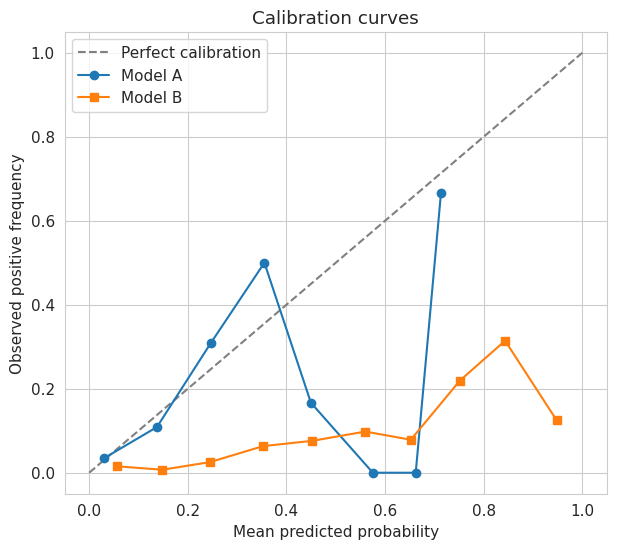

In [29]:
# Cell 34: Reliability diagram
frac_pos_a, mean_pred_a = calibration_curve(y_test, y_prob_a, n_bins=10, strategy="uniform")
frac_pos_b, mean_pred_b = calibration_curve(y_test, y_prob_b, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(mean_pred_a, frac_pos_a, marker="o", label="Model A")
plt.plot(mean_pred_b, frac_pos_b, marker="s", label="Model B")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive frequency")
plt.title("Calibration curves")
plt.legend()
plt.show()

## 9. Additional robust metrics

Two useful complements:
- Matthews Correlation Coefficient (MCC): robust summary even under imbalance
- Cohen's Kappa: agreement corrected for chance

Both discourage over-optimistic interpretations from class prevalence.

In [30]:
# Cell 36: MCC and Kappa at default and min-cost thresholds
def eval_point(y_true, y_prob, threshold):
    y_hat = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "mcc": matthews_corrcoef(y_true, y_hat),
        "kappa": cohen_kappa_score(y_true, y_hat),
        "log_loss": log_loss(y_true, np.vstack([1-y_prob, y_prob]).T)
    }

point_default = eval_point(y_test, y_prob_b, 0.5)
point_cost = eval_point(y_test, y_prob_b, best_threshold)

print(pd.DataFrame([point_default, point_cost]).round(4))

   threshold     mcc   kappa  log_loss
0       0.50  0.2287  0.1674    0.5476
1       0.72  0.2771  0.2607    0.5476


## 10. Multiclass extension

We now move to multiclass evaluation using the Wine dataset. The key idea is that averaging strategy changes interpretation:
- Macro: equal weight to each class
- Weighted: weighted by class support
- Micro: global contributions of all classes

In [31]:
# Cell 38: Load multiclass dataset
wine = load_wine()
X_m = wine.data
y_m = wine.target
class_names = wine.target_names

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_m,
    y_m,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_m
)

scaler_m = StandardScaler()
X_m_train = scaler_m.fit_transform(X_m_train)
X_m_test = scaler_m.transform(X_m_test)

print("Multiclass dataset prepared")
print("Train/Test:", X_m_train.shape, X_m_test.shape)

Multiclass dataset prepared
Train/Test: (124, 13) (54, 13)


In [32]:
# Cell 39: Train multiclass logistic regression
model_m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_m.fit(X_m_train, y_m_train)

y_m_pred = model_m.predict(X_m_test)
y_m_prob = model_m.predict_proba(X_m_test)

print("Multiclass model trained")

Multiclass model trained


In [33]:
# Cell 40: Multiclass report
print(classification_report(y_m_test, y_m_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     class_0     0.9474    1.0000    0.9730        18
     class_1     1.0000    0.9524    0.9756        21
     class_2     1.0000    1.0000    1.0000        15

    accuracy                         0.9815        54
   macro avg     0.9825    0.9841    0.9829        54
weighted avg     0.9825    0.9815    0.9815        54



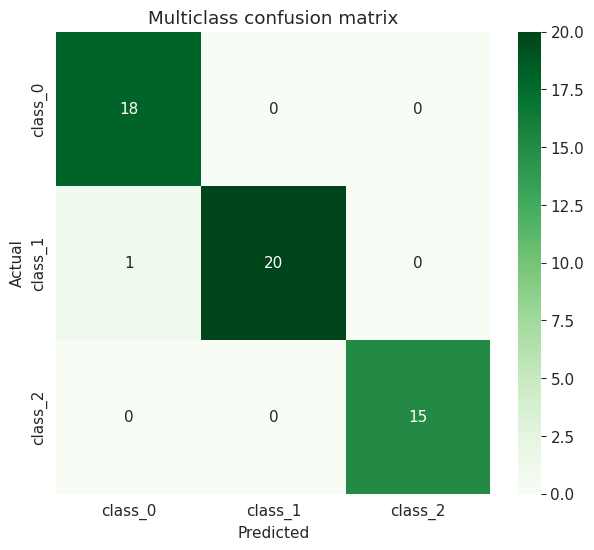

In [34]:
# Cell 41: Multiclass confusion matrix
cm_m = confusion_matrix(y_m_test, y_m_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_m, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.title("Multiclass confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
# Cell 42: Macro, weighted, micro metrics summary
multi_summary = pd.DataFrame([
    {
        "avg": "macro",
        "precision": precision_score(y_m_test, y_m_pred, average="macro", zero_division=0),
        "recall": recall_score(y_m_test, y_m_pred, average="macro", zero_division=0),
        "f1": f1_score(y_m_test, y_m_pred, average="macro", zero_division=0)
    },
    {
        "avg": "weighted",
        "precision": precision_score(y_m_test, y_m_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_m_test, y_m_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_m_test, y_m_pred, average="weighted", zero_division=0)
    },
    {
        "avg": "micro",
        "precision": precision_score(y_m_test, y_m_pred, average="micro", zero_division=0),
        "recall": recall_score(y_m_test, y_m_pred, average="micro", zero_division=0),
        "f1": f1_score(y_m_test, y_m_pred, average="micro", zero_division=0)
    }
])

print(multi_summary.round(4))

        avg  precision  recall      f1
0     macro     0.9825  0.9841  0.9829
1  weighted     0.9825  0.9815  0.9815
2     micro     0.9815  0.9815  0.9815


In [36]:
# Cell 43: Multiclass log loss and top-1 accuracy
multi_logloss = log_loss(y_m_test, y_m_prob)
multi_acc = accuracy_score(y_m_test, y_m_pred)

print(f"Multiclass accuracy: {multi_acc:.4f}")
print(f"Multiclass log loss: {multi_logloss:.4f}")

Multiclass accuracy: 0.9815
Multiclass log loss: 0.0778


## 11. Error analysis table

A practical evaluation report should include representative false positives and false negatives to guide feature engineering and labeling audits.

Here we build a compact error table from the binary test set.

In [37]:
# Cell 45: Build binary error analysis table
error_df = pd.DataFrame({
    "y_true": y_test,
    "prob_pos": y_prob_b,
})
error_df["y_pred_default"] = (error_df["prob_pos"] >= 0.5).astype(int)
error_df["y_pred_cost"] = (error_df["prob_pos"] >= best_threshold).astype(int)

error_df["error_default"] = (error_df["y_true"] != error_df["y_pred_default"]).astype(int)
error_df["error_cost"] = (error_df["y_true"] != error_df["y_pred_cost"]).astype(int)

print("Top uncertain samples (near 0.5):")
print(error_df.iloc[(error_df["prob_pos"] - 0.5).abs().argsort()[:10]].round(4))

Top uncertain samples (near 0.5):
     y_true  prob_pos  y_pred_default  y_pred_cost  error_default  error_cost
130       0    0.4996               0            0              0           0
688       0    0.4989               0            0              0           0
437       0    0.4985               0            0              0           0
208       0    0.4979               0            0              0           0
343       0    0.4967               0            0              0           0
561       0    0.4919               0            0              0           0
580       0    0.4900               0            0              0           0
470       0    0.5114               1            0              1           0
642       0    0.5129               1            0              1           0
176       0    0.4868               0            0              0           0


## 12. Production checklist

Before deployment, verify the following:
1. Metrics include uncertainty intervals, not only point estimates
2. Threshold is chosen for business utility, not convenience
3. Calibration is monitored over time
4. Reporting includes confusion matrix and class-specific metrics
5. Multiclass averaging strategy is documented

In [38]:
# Cell 47: Final consolidated dashboard table
dashboard = pd.DataFrame([
    {
        "section": "binary_default_threshold",
        "accuracy": accuracy_score(y_test, y_pred_b),
        "precision": precision_score(y_test, y_pred_b, zero_division=0),
        "recall": recall_score(y_test, y_pred_b, zero_division=0),
        "f1": f1_score(y_test, y_pred_b, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": ap,
        "brier": brier_b
    },
    {
        "section": "binary_min_cost_threshold",
        "accuracy": accuracy_score(y_test, y_pred_best),
        "precision": precision_score(y_test, y_pred_best, zero_division=0),
        "recall": recall_score(y_test, y_pred_best, zero_division=0),
        "f1": f1_score(y_test, y_pred_best, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": ap,
        "brier": brier_b
    },
    {
        "section": "multiclass",
        "accuracy": multi_acc,
        "precision": precision_score(y_m_test, y_m_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_m_test, y_m_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_m_test, y_m_pred, average="weighted", zero_division=0),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "brier": np.nan
    }
])

print(dashboard.round(4))

                     section  accuracy  precision  recall      f1  roc_auc  pr_auc   brier
0   binary_default_threshold    0.7507     0.1584  0.6531  0.2550   0.7806   0.195  0.1779
1  binary_min_cost_threshold    0.8720     0.2473  0.4694  0.3239   0.7806   0.195  0.1779
2                 multiclass    0.9815     0.9825  0.9815  0.9815      NaN     NaN     NaN


In [39]:
# Cell 48: End-of-notebook summary prints
print("Notebook 05 completed")
print(f"Binary ROC-AUC: {roc_auc:.4f}")
print(f"Binary PR-AUC (AP): {ap:.4f}")
print(f"Best cost threshold: {best_threshold:.2f}")
print(f"Cost at default threshold: {int(default_row['cost'])}")
print(f"Cost at min-cost threshold: {int(best_cost['cost'])}")
print(f"Cost saving: {int(default_row['cost'] - best_cost['cost'])}")
print(f"Multiclass weighted F1: {f1_score(y_m_test, y_m_pred, average='weighted'):.4f}")

Notebook 05 completed
Binary ROC-AUC: 0.7806
Binary PR-AUC (AP): 0.1950
Best cost threshold: 0.72
Cost at default threshold: 4590
Cost at min-cost threshold: 4170
Cost saving: 420
Multiclass weighted F1: 0.9815
